In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [2]:
################################################################################
# PINN for the 2D Wave Equation (First-order System Form)
#
# PDE System:
#   du/dt = v
#   dv/dt = c^2 * (u_xx + u_yy)
# Domain:
#   t in [0, T], x in [0, Lx], y in [0, Ly]
# Initial Conditions:
#   u(0, x, y)  = f1(x, y) = sin(pi*x) * sin(pi*y)
#   v(0, x, y)  = f2(x, y) = 0  (since ut(0, x, y) = 0)
# Boundary Conditions:
#   u(t, 0, y) = u(t, Lx, y) = u(t, x, 0) = u(t, x, Ly) = 0
#   v(t, 0, y) = v(t, Lx, y) = v(t, x, 0) = v(t, x, Ly) = 0
#
################################################################################

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
################################################################################
# Hyperparameters / Problem Setup
################################################################################
Lx = 1.0     # Spatial domain: x in [0, Lx]
Ly = 1.0     # Spatial domain: y in [0, Ly]
T = 1.0      # Temporal domain: t in [0, T]
c = 1.0      # Wave speed

n_collocation = 5000  # Number of collocation points inside domain
n_boundary    = 500   # Number of points for boundary conditions (each boundary)
n_initial     = 1000  # Number of points for initial conditions
hidden_layers = 6     # Number of hidden layers
neurons       = 50    # Neurons per hidden layer
learning_rate = 1e-3  # Learning rate for optimizer
num_epochs    = 12000 # Training epochs

In [4]:
################################################################################
# Neural Network Definition
################################################################################
class PINN(nn.Module):
    def __init__(self, layers, activation=nn.Tanh()):
        super(PINN, self).__init__()
        
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        
        self.activation = activation
        
        # Initialize weights (Xavier initialization)
        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # Forward pass
        for i in range(len(self.linears) - 1):
            x = self.activation(self.linears[i](x))
        # output: [u, v] where v = u_t
        x = self.linears[-1](x)
        return x

In [5]:
################################################################################
# Define the true initial conditions f1(x,y), f2(x,y), and boundary conditions
################################################################################
def f1(x, y):
    # initial displacement: sin(pi*x) * sin(pi*y)
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def f2(x, y):
    # initial velocity: zero
    return np.zeros_like(x)

def boundary_condition_u(t, x, y):
    # Dirichlet boundary conditions for u (all edges)
    return np.zeros_like(t)

def boundary_condition_v(t, x, y):
    # Dirichlet boundary conditions for v (all edges)
    return np.zeros_like(t)

In [6]:
################################################################################
# Exact Solution for the 2D Wave Equation (if available)
################################################################################
def exact_solution_u(x, y, t, c=1.0):
    """
    Exact analytical solution for u: u(x,y,t) = sin(πx) * sin(πy) * cos(c*sqrt(2)*πt)
    """
    omega = np.pi * c * np.sqrt(2)  # Frequency for the (1,1) mode
    return np.sin(np.pi * x) * np.sin(np.pi * y) * np.cos(omega * t)

def exact_solution_v(x, y, t, c=1.0):
    """
    Exact analytical solution for v: v(x,y,t) = du/dt = -c*sqrt(2)*π * sin(πx) * sin(πy) * sin(c*sqrt(2)*πt)
    """
    omega = np.pi * c * np.sqrt(2)  # Frequency for the (1,1) mode
    return -omega * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(omega * t)

def exact_solution_uv(x, y, t, c=1.0):
    """
    Return both u and v as a combined solution
    """
    u = exact_solution_u(x, y, t, c)
    v = exact_solution_v(x, y, t, c)
    return np.column_stack((u.flatten(), v.flatten()))


In [7]:
################################################################################
# Generate Training Data
################################################################################
def generate_training_data():
    # Collocation points in the interior for PDE
    t_coll = np.random.rand(n_collocation, 1) * T
    x_coll = np.random.rand(n_collocation, 1) * Lx
    y_coll = np.random.rand(n_collocation, 1) * Ly

    # Initial condition points (t=0)
    grid_size = int(np.sqrt(n_initial))
    x_init_grid, y_init_grid = np.meshgrid(np.linspace(0, Lx, grid_size), 
                                          np.linspace(0, Ly, grid_size))
    x_init = x_init_grid.flatten().reshape(-1, 1)
    y_init = y_init_grid.flatten().reshape(-1, 1)
    t_init = np.zeros_like(x_init)  # t=0 for all initial points

    # Boundary points (Sample points for each boundary)
    # Bottom boundary (y=0)
    t_bound_bottom = np.random.rand(n_boundary, 1) * T
    x_bound_bottom = np.random.rand(n_boundary, 1) * Lx
    y_bound_bottom = np.zeros((n_boundary, 1))
    
    # Top boundary (y=Ly)
    t_bound_top = np.random.rand(n_boundary, 1) * T
    x_bound_top = np.random.rand(n_boundary, 1) * Lx
    y_bound_top = Ly * np.ones((n_boundary, 1))
    
    # Left boundary (x=0)
    t_bound_left = np.random.rand(n_boundary, 1) * T
    x_bound_left = np.zeros((n_boundary, 1))
    y_bound_left = np.random.rand(n_boundary, 1) * Ly
    
    # Right boundary (x=Lx)
    t_bound_right = np.random.rand(n_boundary, 1) * T
    x_bound_right = Lx * np.ones((n_boundary, 1))
    y_bound_right = np.random.rand(n_boundary, 1) * Ly
    
    # Values for initial conditions
    u_init = f1(x_init, y_init)
    v_init = f2(x_init, y_init)  # v(0,x,y) = u_t(0,x,y) = 0
    uv_init = np.column_stack((u_init.flatten(), v_init.flatten()))

    # Values for boundary conditions (all zeros for this example)
    u_bound_bottom = boundary_condition_u(t_bound_bottom, x_bound_bottom, y_bound_bottom)
    v_bound_bottom = boundary_condition_v(t_bound_bottom, x_bound_bottom, y_bound_bottom)
    uv_bound_bottom = np.column_stack((u_bound_bottom.flatten(), v_bound_bottom.flatten()))
    
    u_bound_top = boundary_condition_u(t_bound_top, x_bound_top, y_bound_top)
    v_bound_top = boundary_condition_v(t_bound_top, x_bound_top, y_bound_top)
    uv_bound_top = np.column_stack((u_bound_top.flatten(), v_bound_top.flatten()))
    
    u_bound_left = boundary_condition_u(t_bound_left, x_bound_left, y_bound_left)
    v_bound_left = boundary_condition_v(t_bound_left, x_bound_left, y_bound_left)
    uv_bound_left = np.column_stack((u_bound_left.flatten(), v_bound_left.flatten()))
    
    u_bound_right = boundary_condition_u(t_bound_right, x_bound_right, y_bound_right)
    v_bound_right = boundary_condition_v(t_bound_right, x_bound_right, y_bound_right)
    uv_bound_right = np.column_stack((u_bound_right.flatten(), v_bound_right.flatten()))

    # Convert everything to tensors
    t_coll = torch.tensor(t_coll, dtype=torch.float32, device=device, requires_grad=True)
    x_coll = torch.tensor(x_coll, dtype=torch.float32, device=device, requires_grad=True)
    y_coll = torch.tensor(y_coll, dtype=torch.float32, device=device, requires_grad=True)
    
    t_init = torch.tensor(t_init, dtype=torch.float32, device=device, requires_grad=True)
    x_init = torch.tensor(x_init, dtype=torch.float32, device=device, requires_grad=True)
    y_init = torch.tensor(y_init, dtype=torch.float32, device=device, requires_grad=True)
    uv_init = torch.tensor(uv_init, dtype=torch.float32, device=device)
    
    # Tensors for boundary points and values
    # Bottom boundary
    t_bound_bottom = torch.tensor(t_bound_bottom, dtype=torch.float32, device=device, requires_grad=True)
    x_bound_bottom = torch.tensor(x_bound_bottom, dtype=torch.float32, device=device, requires_grad=True)
    y_bound_bottom = torch.tensor(y_bound_bottom, dtype=torch.float32, device=device, requires_grad=True)
    uv_bound_bottom = torch.tensor(uv_bound_bottom, dtype=torch.float32, device=device)
    
    # Top boundary
    t_bound_top = torch.tensor(t_bound_top, dtype=torch.float32, device=device, requires_grad=True)
    x_bound_top = torch.tensor(x_bound_top, dtype=torch.float32, device=device, requires_grad=True)
    y_bound_top = torch.tensor(y_bound_top, dtype=torch.float32, device=device, requires_grad=True)
    uv_bound_top = torch.tensor(uv_bound_top, dtype=torch.float32, device=device)
    
    # Left boundary
    t_bound_left = torch.tensor(t_bound_left, dtype=torch.float32, device=device, requires_grad=True)
    x_bound_left = torch.tensor(x_bound_left, dtype=torch.float32, device=device, requires_grad=True)
    y_bound_left = torch.tensor(y_bound_left, dtype=torch.float32, device=device, requires_grad=True)
    uv_bound_left = torch.tensor(uv_bound_left, dtype=torch.float32, device=device)
    
    # Right boundary
    t_bound_right = torch.tensor(t_bound_right, dtype=torch.float32, device=device, requires_grad=True)
    x_bound_right = torch.tensor(x_bound_right, dtype=torch.float32, device=device, requires_grad=True)
    y_bound_right = torch.tensor(y_bound_right, dtype=torch.float32, device=device, requires_grad=True)
    uv_bound_right = torch.tensor(uv_bound_right, dtype=torch.float32, device=device)

    # Bundle data
    collocation_pts = (t_coll, x_coll, y_coll)
    initial_pts = (t_init, x_init, y_init, uv_init)
    boundary_pts = {
        'bottom': (t_bound_bottom, x_bound_bottom, y_bound_bottom, uv_bound_bottom),
        'top': (t_bound_top, x_bound_top, y_bound_top, uv_bound_top),
        'left': (t_bound_left, x_bound_left, y_bound_left, uv_bound_left),
        'right': (t_bound_right, x_bound_right, y_bound_right, uv_bound_right)
    }

    return collocation_pts, initial_pts, boundary_pts

In [8]:
################################################################################
# Physics-Informed Loss Function (First-order System Form)
################################################################################
def wave_pde_loss(model, t, x, y):
    """
    Compute PDE residual for the first-order system:
    du/dt = v
    dv/dt = c^2 * (u_xx + u_yy)
    """
    # Ensure gradients are computed
    t.requires_grad_(True)
    x.requires_grad_(True)
    y.requires_grad_(True)

    # NN output: [u, v]
    inputs = torch.cat((t, x, y), dim=1)
    uv = model(inputs)
    u = uv[:, [0]]  # u component
    v = uv[:, [1]]  # v component (should be u_t)

    # First derivatives of u
    u_grads = torch.autograd.grad(u, inputs, 
                                 grad_outputs=torch.ones_like(u), 
                                 create_graph=True)[0]
    u_t = u_grads[:, [0]]
    u_x = u_grads[:, [1]]
    u_y = u_grads[:, [2]]

    # First derivatives of v
    v_grads = torch.autograd.grad(v, inputs,
                                 grad_outputs=torch.ones_like(v),
                                 create_graph=True)[0]
    v_t = v_grads[:, [0]]

    # Second spatial derivatives of u
    u_xx = torch.autograd.grad(u_x, x,
                              grad_outputs=torch.ones_like(u_x),
                              create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y,
                              grad_outputs=torch.ones_like(u_y),
                              create_graph=True)[0]

    # PDE residuals for the first-order system:
    # Equation 1: du/dt = v
    f_u = u_t - v
    
    # Equation 2: dv/dt = c^2 * (u_xx + u_yy)
    f_v = v_t - (c**2) * (u_xx + u_yy)

    return torch.mean(f_u**2) + torch.mean(f_v**2)


def initial_condition_loss(model, t, x, y, uv_true):
    """
    Compute loss for initial conditions: u(0,x,y) = f1(x,y) and v(0,x,y) = f2(x,y)
    """
    inputs = torch.cat((t, x, y), dim=1)
    uv_pred = model(inputs)
    ic_loss = torch.mean((uv_pred - uv_true)**2)
    
    return ic_loss


def boundary_condition_loss(model, boundary_pts):
    """
    Compute loss for boundary conditions at all four edges of the domain.
    """
    bc_loss = 0
    
    # Process each boundary
    for boundary_name, (t, x, y, uv_true) in boundary_pts.items():
        inputs = torch.cat((t, x, y), dim=1)
        uv_pred = model(inputs)
        bc_loss += torch.mean((uv_pred - uv_true)**2)
    
    return bc_loss


def loss_function(model, collocation_pts, initial_pts, boundary_pts):
    """
    Compute total loss for the PINN.
    """
    # Unpack data
    t_coll, x_coll, y_coll = collocation_pts
    t_init, x_init, y_init, uv_init = initial_pts
    
    # PDE residual loss
    pde_loss = wave_pde_loss(model, t_coll, x_coll, y_coll)
    
    # Initial condition loss
    ic_loss = initial_condition_loss(model, t_init, x_init, y_init, uv_init)
    
    # Boundary condition loss
    bc_loss = boundary_condition_loss(model, boundary_pts)
    
    # Combine losses with appropriate weights
    total_loss = pde_loss + ic_loss + bc_loss
    
    return total_loss, pde_loss, ic_loss, bc_loss

In [9]:
################################################################################
# Training Setup and Execution
################################################################################
# Generate training data
collocation_pts, initial_pts, boundary_pts = generate_training_data()

# Create model (now outputs 2 components: [u, v])
layers = [3] + [neurons]*hidden_layers + [2]  # 3 inputs: (t, x, y), 2 outputs: [u, v]
model = PINN(layers, activation=nn.Tanh()).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1000)


print("Starting training...")
num_epochs = 12000  # 修改迭代次数
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Compute loss
    loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    # Update learning rate
    scheduler.step(loss)
    
    # Print progress
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Loss: {loss.item():.6e}, "
              f"PDE Loss: {pde_loss.item():.6e}, "
              f"IC Loss: {ic_loss.item():.6e}, "
              f"BC Loss: {bc_loss.item():.6e}")

print("Training completed!")

Starting training...
Epoch [500/12000], Loss: 9.209521e-02, PDE Loss: 3.595988e-03, IC Loss: 7.784479e-02, BC Loss: 1.065443e-02
Epoch [1000/12000], Loss: 8.764223e-02, PDE Loss: 4.498571e-03, IC Loss: 6.692852e-02, BC Loss: 1.621514e-02
Epoch [1500/12000], Loss: 7.925089e-02, PDE Loss: 6.854774e-03, IC Loss: 5.899069e-02, BC Loss: 1.340542e-02
Epoch [2000/12000], Loss: 7.165286e-02, PDE Loss: 8.450121e-03, IC Loss: 5.059943e-02, BC Loss: 1.260331e-02
Epoch [2500/12000], Loss: 6.058785e-02, PDE Loss: 9.709811e-03, IC Loss: 3.916325e-02, BC Loss: 1.171478e-02
Epoch [3000/12000], Loss: 4.888565e-02, PDE Loss: 8.649113e-03, IC Loss: 2.934163e-02, BC Loss: 1.089490e-02
Epoch [3500/12000], Loss: 4.063387e-02, PDE Loss: 8.957621e-03, IC Loss: 2.168288e-02, BC Loss: 9.993364e-03
Epoch [4000/12000], Loss: 3.312117e-02, PDE Loss: 8.179126e-03, IC Loss: 1.587480e-02, BC Loss: 9.067241e-03
Epoch [4500/12000], Loss: 2.840347e-02, PDE Loss: 7.355106e-03, IC Loss: 1.282832e-02, BC Loss: 8.220041e-03

Processing t=0: t = 0.0000
Max |u error| at t=0: 7.626247e-02
Mean |u error| at t=0: 2.946548e-02
Processing t=0.5: t = 0.5000
Max |u error| at t=0.5: 9.785091e-02
Mean |u error| at t=0.5: 4.406510e-02
Processing t=1.0: t = 1.0000
Max |u error| at t=1.0: 4.818983e-02
Mean |u error| at t=1.0: 1.458444e-02


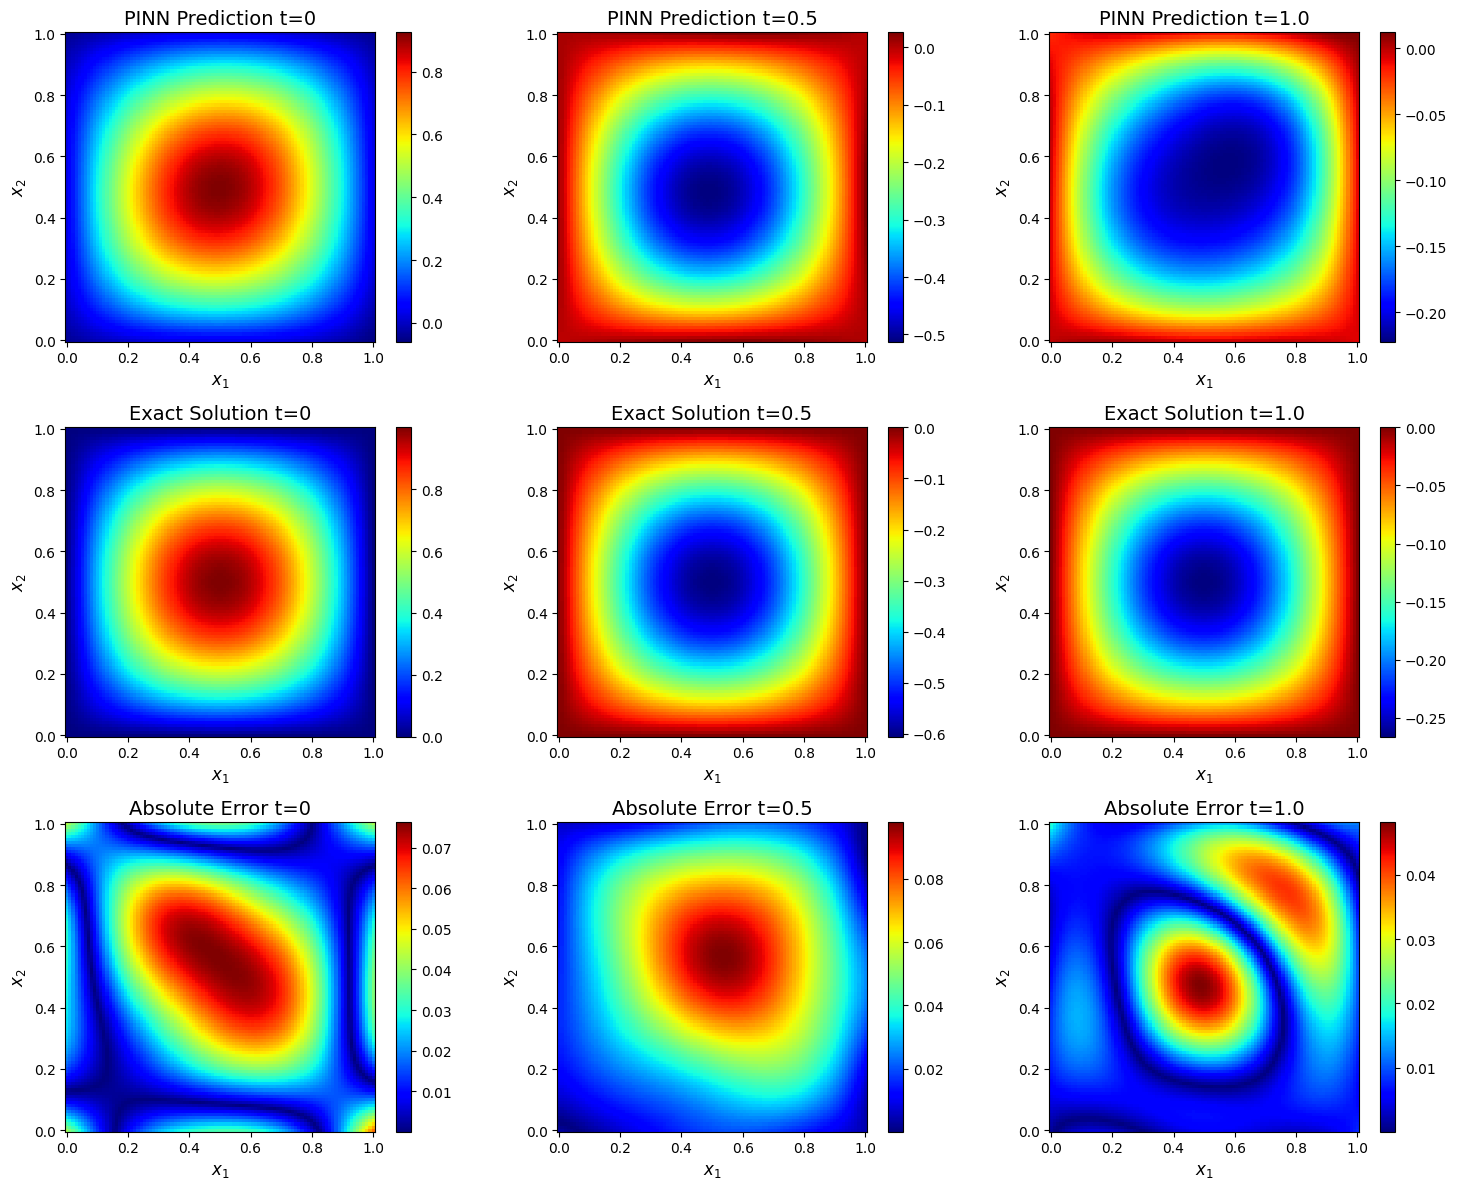

显示了 255 个采样点在 t=0
显示了 482 个采样点在 t=0.5
显示了 272 个采样点在 t=1.0


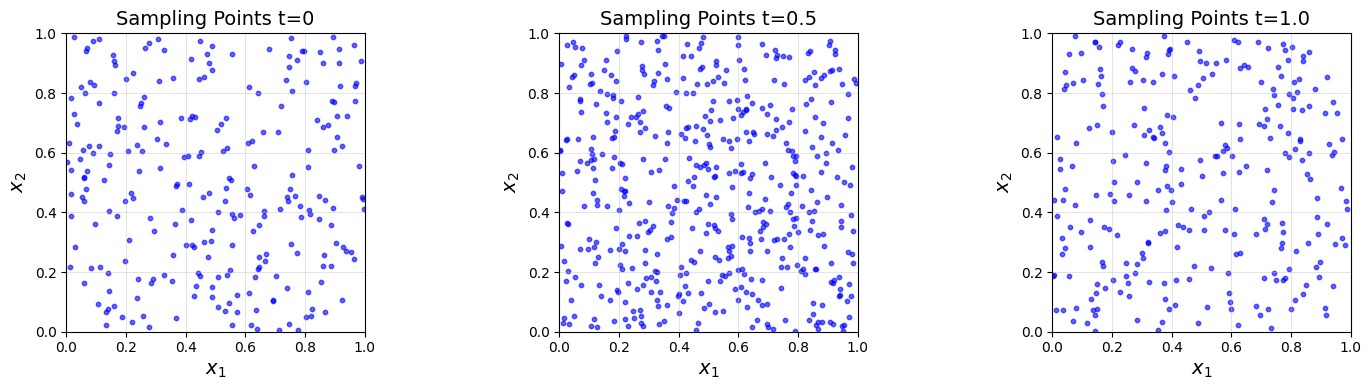


计算最终L2误差...
最终L2误差: 4.263706e-02


In [10]:
# 定义三个关键时间点
time_values = [0.0, 0.5, 1.0]
time_labels = ['t=0', 't=0.5', 't=1.0']

# 创建网格
x_grid = np.linspace(0, Lx, 100)
y_grid = np.linspace(0, Ly, 100)
X, Y = np.meshgrid(x_grid, y_grid)

# 创建3x3子图
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# 为每个时间点生成数据
for time_idx, (t_val, t_label) in enumerate(zip(time_values, time_labels)):
    print(f"Processing {t_label}: t = {t_val:.4f}")
    
    # 准备输入张量
    t_tensor = torch.full((X.size, 1), t_val, dtype=torch.float32, device=device)
    x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    
    # PINN预测
    with torch.no_grad():
        inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
        uv_pred = model(inputs).cpu().numpy()
        u_pred = uv_pred[:, 0].reshape(X.shape)
    
    # 精确解
    u_exact = exact_solution_u(X, Y, t_val)
    
    # 误差
    error_u = np.abs(u_pred - u_exact)
    
    # 第一行：PINN预测
    im1 = axes[0, time_idx].pcolormesh(X, Y, u_pred, cmap='jet', shading='auto')
    axes[0, time_idx].set_title(f'PINN Prediction {t_label}', fontsize=14)
    axes[0, time_idx].set_xlabel('$x_1$', fontsize=12)
    axes[0, time_idx].set_ylabel('$x_2$', fontsize=12)
    axes[0, time_idx].set_aspect('equal')
    plt.colorbar(im1, ax=axes[0, time_idx])
    
    # 第二行：精确解
    im2 = axes[1, time_idx].pcolormesh(X, Y, u_exact, cmap='jet', shading='auto')
    axes[1, time_idx].set_title(f'Exact Solution {t_label}', fontsize=14)
    axes[1, time_idx].set_xlabel('$x_1$', fontsize=12)
    axes[1, time_idx].set_ylabel('$x_2$', fontsize=12)
    axes[1, time_idx].set_aspect('equal')
    plt.colorbar(im2, ax=axes[1, time_idx])
    
    # 第三行：误差
    im3 = axes[2, time_idx].pcolormesh(X, Y, error_u, cmap='jet', shading='auto')
    axes[2, time_idx].set_title(f'Absolute Error {t_label}', fontsize=14)
    axes[2, time_idx].set_xlabel('$x_1$', fontsize=12)
    axes[2, time_idx].set_ylabel('$x_2$', fontsize=12)
    axes[2, time_idx].set_aspect('equal')
    plt.colorbar(im3, ax=axes[2, time_idx])
    
    # 输出误差统计
    print(f"Max |u error| at {t_label}: {np.max(error_u):.6e}")
    print(f"Mean |u error| at {t_label}: {np.mean(error_u):.6e}")

plt.tight_layout()
plt.show()

################################################################################
# 采样点可视化（3个时间点的采样点分布）
################################################################################

# 提取采样点数据
t_coll, x_coll, y_coll = collocation_pts
t_coll_np = t_coll.detach().cpu().numpy()
x_coll_np = x_coll.detach().cpu().numpy()
y_coll_np = y_coll.detach().cpu().numpy()

# 创建1x3子图显示采样点分布
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for time_idx, (t_val, t_label) in enumerate(zip(time_values, time_labels)):
    # 选择接近指定时间的点
    time_tolerance = T / 20
    time_mask = np.abs(t_coll_np.flatten() - t_val) < time_tolerance
    
    if np.sum(time_mask) > 10:
        # 获取该时间点附近的采样点
        x_points = x_coll_np[time_mask]
        y_points = y_coll_np[time_mask]
        
        # 随机采样以避免图像过于密集
        if len(x_points) > 1000:
            indices = np.random.choice(len(x_points), 1000, replace=False)
            x_display = x_points[indices]
            y_display = y_points[indices]
        else:
            x_display = x_points
            y_display = y_points
        
        # 绘制采样点
        axes[time_idx].scatter(x_display, y_display, c='blue', s=10, alpha=0.6)
        axes[time_idx].set_xlim(0, Lx)
        axes[time_idx].set_ylim(0, Ly)
        axes[time_idx].set_xlabel('$x_1$', fontsize=14)
        axes[time_idx].set_ylabel('$x_2$', fontsize=14)
        axes[time_idx].set_title(f'Sampling Points {t_label}', fontsize=14)
        axes[time_idx].grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
        axes[time_idx].set_aspect('equal')
        
        print(f"显示了 {len(x_display)} 个采样点在 {t_label}")
    else:
        axes[time_idx].text(0.5, 0.5, f'No points\nnear {t_label}', 
                           ha='center', va='center', transform=axes[time_idx].transAxes)
        axes[time_idx].set_xlim(0, Lx)
        axes[time_idx].set_ylim(0, Ly)
        axes[time_idx].set_xlabel('$x_1$', fontsize=14)
        axes[time_idx].set_ylabel('$x_2$', fontsize=14)
        axes[time_idx].set_title(f'Sampling Points {t_label}', fontsize=14)
        print(f"{t_label}: 采样点数量不足 (只有 {np.sum(time_mask)} 个点)")

plt.tight_layout()
plt.show()

################################################################################
# 计算并输出L2误差
################################################################################
print("\n" + "="*50)
print("计算最终L2误差...")

# 生成测试点
n_test_points = 8000
n_per_dim = int(np.cbrt(n_test_points))

t_test = torch.linspace(0, T, n_per_dim)
x_test = torch.linspace(0, Lx, n_per_dim)
y_test = torch.linspace(0, Ly, n_per_dim)

T_test, X_test, Y_test = torch.meshgrid(t_test, x_test, y_test, indexing='ij')
t_flat = T_test.reshape(-1, 1)
x_flat = X_test.reshape(-1, 1)
y_flat = Y_test.reshape(-1, 1)

txy_test = torch.cat([t_flat, x_flat, y_flat], dim=1).to(device)

# 获取模型预测
with torch.no_grad():
    outputs = model(txy_test)
    u_pred = outputs[:, 0:1]  # 只取u分量

# 计算解析解
t_np = t_flat.cpu().numpy()
x_np = x_flat.cpu().numpy()
y_np = y_flat.cpu().numpy()
u_exact = exact_solution_u(x_np, y_np, t_np)
u_exact_tensor = torch.tensor(u_exact, dtype=torch.float32).to(device)

# 计算L2误差
l2_error = torch.sqrt(torch.mean((u_pred - u_exact_tensor)**2))

print(f"最终L2误差: {l2_error.item():.6e}")
print("="*50)